# Lecture 34. 서로소 집합 자료구조를 활용한 사이클 판별

## 0. 목차
1. 서로소 집합을 활용한 사이클 판별
2. 서로소 집합을 활용한 사이클 판별: 동작 과정 살펴보기
3. 서로소 집합을 활용한 사이클 판별: 소스코드

## 1. 서로소 집합을 활용한 사이클 판별

- 서로소 집합은 무방향 그래프 내에서의 사이클을 판별할 때 사용할 수 있다.
    - 참고로 방향 그래프에서의 사이클 여부는 DFS를 이용하여 판별할 수 있다.
- 사이클 판별 알고리즘은 다음과 같다.
1. 각 간선을 하나씩 확인하며 두 노드의 루트 노드를 확인한다.
    1) 루트 노드가 서로 다르다면 두 노드에 대하여 합집합(Union)연산을 수행한다.
    2) 루트 노드가 서로 같다면 사이클(Cycle)이 발생한 것이다.
2. 그래프에 포함되어 있는 모든 간선에 대하여 1번 과정을 반복한다.

## 2. 서로소 집합을 활용한 사이클 판별: 동작 과정 살펴보기
[초기 단계] 모든 노드에 대하여 자기 자신을 부모로 설정하는 형태로 부모 테이블을 초기화한다.

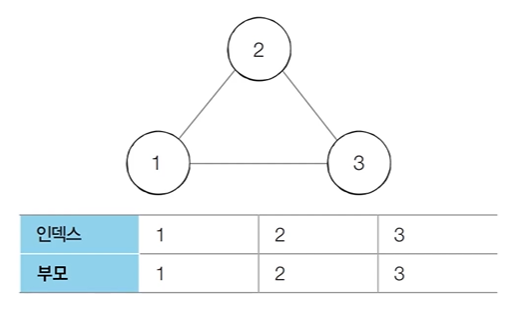

[Step 1] 간선 (1, 2)를 확인한다. 노드 1과 노드 2의 루트 노드는 각각 1과 2이다. 따라서 더 큰 번호에 해당하는 노드 2의 부모 노드를 1로 변경한다.

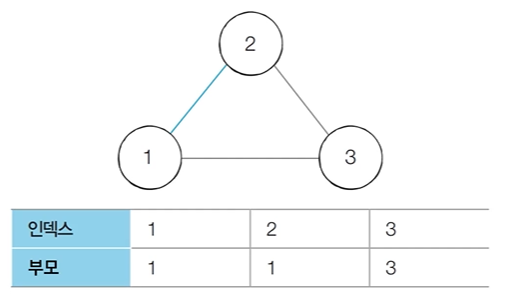

[Step 2] 간선 (1, 3)을 확인한다. 노드 1과 노드 3의 루트 노드는 각각 1과 3이다. 따라서 더 큰 번호에 해당하는 노드 3의 부모 노드를 1로 변경한다.

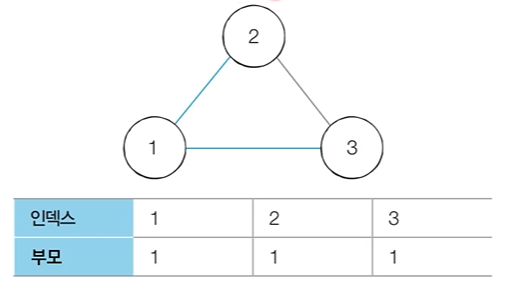

[Step 3] 간선 (2, 3)을 확인한다. 이미 노드 2와 노드 3의 루트 노드는 모두 1이다. 다시 말해 사이클이 발생한다는 것을 알 수 있다.

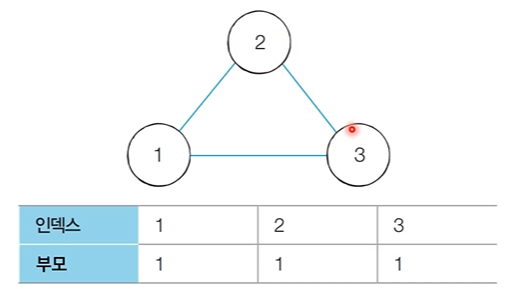

## 3. 서로소 집합을 활용한 사이클 판별: 소스코드

### 구현 연습


In [ ]:
# 찾기 함수

def find_parent(parent, x):
    if parent[x] != x:
        parent[x] = find_parent(parent, parent[x])
    return parent[x]

# 합집합 함수

def union(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a > b:
        parent[a] = b
    else:
        parent[b] = a


v, e = map(int, input().split())
parent = [0] * (v+1)
for i in range(1, v+1):
    parent[i] = i

cycle  = False

for _ in range(e):
    a, b = map(int, input().split())


### 정답

```python
# 특정 원소가 속한 집합을 찾기
def find_parent(parent, x):
    # 루트 노드를 찾을 때까지 재귀 호출
    if parent[x] != x:
        parent[x] = find_parent(parent, parent[x])
    return parent[x]

# 두 원소가 속한 집합을 합치기
def union_parent(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a < b:
        parent[b] = a
    else:
        parent[a] = b

# 노드의 개수와 간선(Union 연산)의 개수 입력 받기
v, e = map(int, input().split())
parent = [0] * (v+1) # 부모 테이블 초기화하기

# 부모 테이블상에서, 부모를 자기 자신으로 초기화
for i in range(1, v+1):
    parent[i] = i

cycle = False # 사이클 발생 여부

for i in range(e):
    a, b = map(int, input().split())
    # 사이클이 발생한 경우 종료
    if find_parent(parent, a) == find_parent(parent, b):
        cycle = True
        break
    # 사이클이 발생하지 않았다면 합집합(Union) 연산 수행
    else:
        union_parent(parent, a, b)

if cycle:
    print("사이클이 발생했습니다.")
else:
    print("사이클이 발생하지 않았습니다.")
```

### 정리 및 회고

#### 순서
1. 서로소 집합을 활용한 사이클 판별
2. 서로소 집합을 활용한 사이클 판별: 동작 과정 살펴보기
3. 서로소 집합을 활용한 사이클 판별: 소스코드

#### 키워드
서로소 집합 

#### 회고
1. 서로소 집합으로 사이클을 판별할 때 왜 합집합을 이용하는지 전체적인 구조가 잘 이해가 가지 않았는데, ai한테 물어보면서 이해하니까 코드 구현도 비교적 쉽고 이해도 빨랐음.
